Initial combined shape: (13600, 14)
After cleaning: (5550, 20)

AUCs by class:
 0: 0.843
 1: 0.698
 2: 0.952

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.73      0.76       797
         1.0       0.46      0.50      0.48       401
         2.0       0.66      0.80      0.72       190

    accuracy                           0.67      1388
   macro avg       0.64      0.68      0.66      1388
weighted avg       0.68      0.67      0.68      1388


Mean predicted probabilities by true A1C class:
      P_prediab    P_diab
true                     
0.0    0.348977  0.088899
1.0    0.420856  0.232021
2.0    0.301894  0.620381


c:\python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\branjan\AppData\Local\Temp\ipykernel_31724\1670024400.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meanprob.index, y=meanprob["P_diab"], palette="mako")


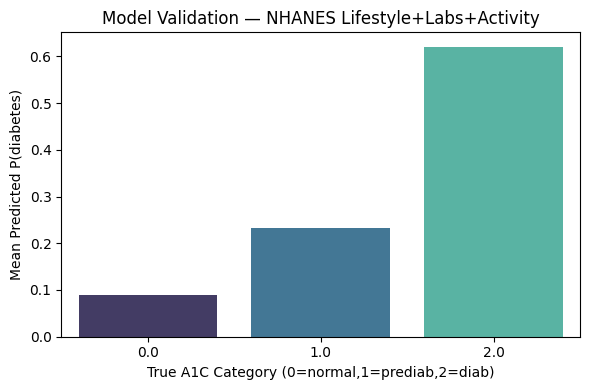


Spearman correlation between A1C category and predicted diabetes prob: r=1.000, p=0

Saved nhanes_diabetes.joblib successfully.


In [1]:
import pandas as pd, numpy as np, joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
import seaborn as sns, matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.inspection import PartialDependenceDisplay

#read .XPT(SAS transport) files
def read_xpt(p): 
    return pd.read_sas(p, format='xport')

#Load 2017–2018,2021–2023 files
#A1C
ghb_1718 = read_xpt("../data/nhanes/GHB_J.XPT")[["SEQN","LBXGH"]]
ghb_2123 = read_xpt("../data/nhanes/GHB_L.XPT")[["SEQN","LBXGH"]]

#Fasting glucose
glu_1718 = read_xpt("../data/nhanes/GLU_J.XPT")[["SEQN","LBXGLU"]]
glu_2123 = read_xpt("../data/nhanes/GLU_L.XPT")[["SEQN","LBXGLU"]]

#Demographics
demo_1718 = read_xpt("../data/nhanes/DEMO_J.XPT")[["SEQN","RIDAGEYR","RIAGENDR","RIDRETH3"]]
demo_2123 = read_xpt("../data/nhanes/DEMO_L.XPT")[["SEQN","RIDAGEYR","RIAGENDR","RIDRETH3"]]

#BMI,Hypertension,Smoking
bmx_1718=read_xpt("../data/nhanes/BMX_J.XPT")[["SEQN","BMXBMI"]]
bmx_2123=read_xpt("../data/nhanes/BMX_L.XPT")[["SEQN","BMXBMI"]]
bpq_1718=read_xpt("../data/nhanes/BPQ_J.XPT")[["SEQN","BPQ020"]]
bpq_2123=read_xpt("../data/nhanes/BPQ_L.XPT")[["SEQN","BPQ020"]]
smq_1718=read_xpt("../data/nhanes/SMQ_J.XPT")[["SEQN","SMQ020"]]
smq_2123=read_xpt("../data/nhanes/SMQ_L.XPT")[["SEQN","SMQ020"]]

#Physical activity (different variables per cycle)
paq_1718=read_xpt("../data/nhanes/PAQ_J.XPT")[["SEQN","PAQ605","PAQ620"]]
paq_2123=read_xpt("../data/nhanes/PAQ_L.XPT")[["SEQN","PAD790Q","PAD810Q","PAD680"]]

#Combine into one dataset
df_1718=(ghb_1718.merge(glu_1718, on="SEQN", how="left")
                     .merge(demo_1718, on="SEQN", how="left")
                     .merge(bmx_1718, on="SEQN", how="left")
                     .merge(bpq_1718, on="SEQN", how="left")
                     .merge(smq_1718, on="SEQN", how="left")
                     .merge(paq_1718, on="SEQN", how="left"))

df_2123=(ghb_2123.merge(glu_2123, on="SEQN", how="left")
                     .merge(demo_2123, on="SEQN", how="left")
                     .merge(bmx_2123, on="SEQN", how="left")
                     .merge(bpq_2123, on="SEQN", how="left")
                     .merge(smq_2123, on="SEQN", how="left")
                     .merge(paq_2123, on="SEQN", how="left"))

df=pd.concat([df_1718, df_2123], ignore_index=True)

df=df.rename(columns={
    "LBXGH":"A1C", "LBXGLU":"GLU", "RIDAGEYR":"AGE", "RIAGENDR":"SEX",
    "BMXBMI":"BMI", "BPQ020":"HTN", "SMQ020":"SMOKE", "RIDRETH3":"RACE"
})

print("Initial combined shape:", df.shape)

#Define target and map predictors
def a1c_band(a):
    if pd.isna(a): return np.nan
    if a < 5.7: return 0  # normal
    if a < 6.5: return 1  # prediabetes
    return 2              # diabetes
df["Y"] = df["A1C"].apply(a1c_band)

#Map Binary flags
df["SEX_MALE"]=(df["SEX"]==1).astype(int)
df["HTN_FLAG"]=df["HTN"].map({1:1, 2:0})
df["SMOKING_IDX"]=df["SMOKE"].map({1:1, 2:0})
df["RACE_CAT"]=df["RACE"]

#Physical activity flag
df["PA_ANY"]=np.where(
    (df.get("PAQ605",0)==1) | (df.get("PAQ620",0)==1) |
    (df.get("PAD790Q",0)>0) | (df.get("PAD810Q",0)>0) | (df.get("PAD680",0)==1),
    1,0
)

#restrict to adults with valid A1C
df=df[(df["AGE"] >= 20) & (df["AGE"] <= 80)]
features=["AGE","BMI","SEX_MALE","HTN_FLAG","SMOKING_IDX","GLU","PA_ANY"]
df=df.dropna(subset=features+["Y"])

print("After cleaning:", df.shape)

#Split and train balanced logistic regression
X=df[features]
y=df["Y"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

pipe=Pipeline([
    ("scale",StandardScaler()),
    ("clf",LogisticRegression(max_iter=1000, multi_class="ovr", class_weight="balanced"))
])

pipe.fit(Xtr,ytr)

print("\nAUCs by class:")
for k in [0,1,2]:
    auc=roc_auc_score((yte==k).astype(int),pipe.predict_proba(Xte)[:,k])
    print(f" {k}: {auc:.3f}")

print("\nClassification Report:\n",classification_report(yte,pipe.predict(Xte)))

#Check monotonic probability trend
prob=pipe.predict_proba(Xte)
pred=pd.DataFrame(prob, columns=["P_normal","P_prediab","P_diab"])
pred["true"] = yte.values

meanprob = pred.groupby("true")[["P_prediab","P_diab"]].mean()
print("\nMean predicted probabilities by true A1C class:")
print(meanprob)

#Visualize risk progression
plt.figure(figsize=(6,4))
sns.barplot(x=meanprob.index, y=meanprob["P_diab"], palette="mako")
plt.ylabel("Mean Predicted P(diabetes)")
plt.xlabel("True A1C Category (0=normal,1=prediab,2=diab)")
plt.title("Model Validation — NHANES Lifestyle+Labs+Activity")
plt.tight_layout()
plt.show()

#Spearman correlation
r, p = spearmanr(meanprob.index, meanprob["P_diab"])
print(f"\nSpearman correlation between A1C category and predicted diabetes prob: r={r:.3f}, p={p:.3g}")

joblib.dump(pipe,"../models/nhanes_diabetes.joblib")
print("\nSaved nhanes_diabetes.joblib successfully.")

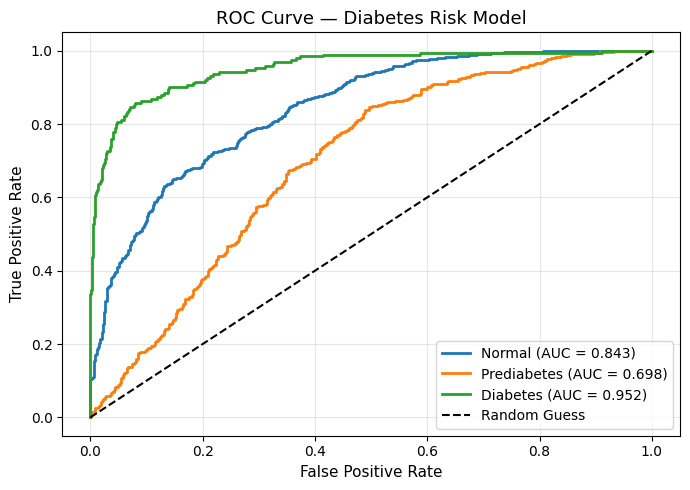

In [3]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- ROC curve with readable labels ---
classes = [0, 1, 2]
class_names = {
    0: "Normal",
    1: "Prediabetes",
    2: "Diabetes"
}

yte_bin = label_binarize(yte, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[cls], tpr[cls], _ = roc_curve(yte_bin[:, i], prob[:, i])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

plt.figure(figsize=(7, 5))

for cls in classes:
    plt.plot(
        fpr[cls],
        tpr[cls],
        linewidth=2,
        label=f"{class_names[cls]} (AUC = {roc_auc[cls]:.3f})"
    )

# Chance line
plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Guess")

plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve — Diabetes Risk Model", fontsize=13)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import json
import numpy as np

#Extract regression coefficients
clf=pipe.named_steps["clf"]
scaler=pipe.named_steps["scale"]

featureNames=X.columns.tolist()

#Compute average
importance=np.mean(np.abs(clf.coef_), axis=0)

#Change to percentage
percent=100*importance/np.sum(importance)

data=[
    {"feature": f, "percent": float(round(p, 2))}
    for f, p in zip(featureNames, percent)
]

#Sort descending order
data=sorted(data, key=lambda x: x["percent"], reverse=True)

#Export feature importance
path = Path("../models/gluco_risk_feature_importance.json")
with open(path, "w") as f:
    json.dump(data, f, indent=2)

print(f"\nSaved feature importance to {path}")

for item in data:
    print(f"{item['feature']:<15} {item['percent']:>6.2f}%")


✅ Saved feature importance to ..\models\gluco_risk_feature_importance.json
GLU              56.91%
AGE              20.95%
BMI              10.91%
HTN_FLAG          4.39%
PA_ANY            3.63%
SEX_MALE          1.94%
SMOKING_IDX       1.28%


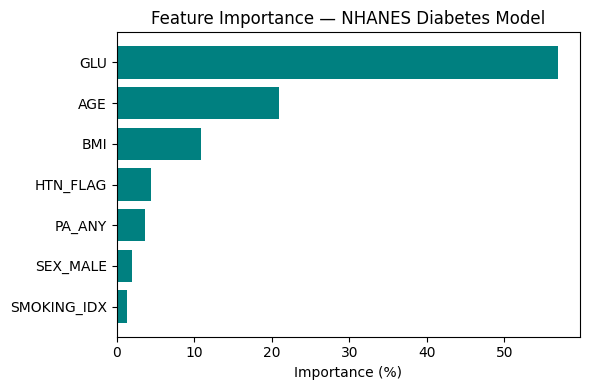

In [ ]:
#Plot importance data
plt.figure(figsize=(6, 4))
plt.barh([x["feature"] for x in data[::-1]],
         [x["importance_percent"] for x in data[::-1]],
         color="teal")
plt.xlabel("Importance (%)")
plt.title("Feature Importance - NHANES Diabetes Model")
plt.tight_layout()
plt.show()

In [ ]:
import joblib
model = joblib.load("../models/nhanes_diabetes.joblib")
print(model.named_steps["scale"].feature_names_in_)

['AGE' 'BMI' 'SEX_MALE' 'HTN_FLAG' 'SMOKING_IDX' 'GLU' 'PA_ANY']


In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import joblib, numpy as np
from sklearn.linear_model import LogisticRegression
import onnx

#Load Model
model = joblib.load("../models/nhanes_diabetes.joblib")
scaler = model.named_steps["scale"]
clf = model.named_steps["clf"]

#Collapse scaler math into linear coefficients
W=clf.coef_/scaler.scale_
b=clf.intercept_-np.sum((clf.coef_ * scaler.mean_)/scaler.scale_,axis=1)

#Create clean LogisticRegression object
simple_clf = LogisticRegression()
simple_clf.classes_=clf.classes_
simple_clf.coef_=W
simple_clf.intercept_=b
simple_clf.n_features_in_=7
simple_clf.n_iter_=np.array([1])  # required metadata

#Explicitly set ONNX input type
type = [("float_input", FloatTensorType([None, 7]))]

onnx_model = convert_sklearn(simple_clf, initial_types=type, target_opset=17, options={"zipmap": False} )

path = "../models/nhanes_diabetes.onnx"
#save the model
onnx.save(onnx_model,path)
print("Exported simplified ONNX model to",path)

In [ ]:
import onnxruntime as rt
import numpy as np

session=rt.InferenceSession("../models/nhanes_diabetes.onnx")

#Inputs
input_name=session.get_inputs()[0].name

#Outputs
output_names = [o.name for o in session.get_outputs()]
print("Inputs:",input_name)
print("Outputs:",output_names)

#example
#AGE,BMI,SEX_MALE,HTN_FLAG,SMOKING_IDX,GLU,PA_ANY
x = np.array([[20, 22, 1, 0, 0, 110, 0]],dtype=np.float32)

#Find Predicted prob
pred=session.run(None, {input_name: x})

print("Predicted probabilities:", pred)

Inputs: float_input
Outputs: ['label', 'probabilities']
Predicted probabilities: [array([0]), array([[0.9443647 , 0.04447773, 0.0111576 ]], dtype=float32)]
